### Imports

In [36]:
import torch
import random
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib import colormaps
from collections import deque

from MyoElbowPose2D6M import MyoElbowPose2D6MFixed

### Constants

In [37]:
# --- Simulation parameters ---
dt, tau_n, tau_m = 0.01, 0.02, 0.05

# --- Neural network parameters ---
n_s, n_m1, n_muscles, n_inputs = 200, 200, 6, 10

# --- Feedback gains ---
G_p, G_d, G_f = 1.0, 1.0, 1.0

# --- Reflex parameters ---
G_aff = torch.tensor([1.0, 0.1, 0.01, 0.0001])
G_s_low, G_s_high = 0.8, 1.9
reflex_delay = int(0.02 / dt)

# --- Activation and feedback delay ---
activation_delay_steps = int(0.03 / dt)
feedback_delay_steps = int(0.04 / dt) 

# --- Moment arm matrix ---
M_m = torch.tensor([[0.1, 0.02], [0.08, 0.01], [0.06, 0.01], [-0.06, -0.02], [-0.08, -0.01], [-0.1, -0.02]])

# --- Penalty coefficients ---
alpha, beta, gamma = 0.0001, 0.01, 0.5

# --- External loads ---
background_load_low, background_load_high, perturbation_load = 0.1, 0.55, 0.25

# --- Time parameters and steps ---
Tb, Tsb, Tp, Tsp, T = 0.20, 1.00, 1.50, 2.50, 3.00
Tb_step, Tsb_step, Tp_step, Tsp_step, T_step = int(Tb / dt), int(Tsb / dt), int(Tp / dt), int(Tsp / dt), int(T / dt)

# --- Perturbation directions ---
scale_factor = 10
perturbation_directions = {
    "Right": scale_factor * np.array([1.0, 0.0]), "Left": scale_factor * np.array([-1.0, 0.0]),
    "Up": scale_factor * np.array([0.0, 1.0]), "Down": scale_factor * np.array([0.0, -1.0]),
    "Up-Right": scale_factor * np.array([0.707, 0.707]), "Up-Left": scale_factor * np.array([-0.707, 0.707]),
    "Down-Left": scale_factor * np.array([-0.707, -0.707]), "Down-Right": scale_factor * np.array([0.707, -0.707])}

# --- Arm segment lengths ---
l1, l2 = 0.12, 0.10

### Neural Limb Controller

In [38]:
class NeuralLimbController(nn.Module):
    """Neural controller for a two-segment limb model."""

    def __init__(self, n_inputs, n_outputs=n_muscles):
        super().__init__()
        
        # Sensory layer
        self.w_sr = self._init_weights(n_s, n_s, n_inputs)
        self.w_si = self._init_weights(n_s, n_inputs, n_inputs)
        self.b_s = nn.Parameter(torch.full((n_s,), 0.1))

        # M1 layer
        self.w_mr = self._init_weights(n_m1, n_m1, n_s)
        self.w_mi = self._init_weights(n_m1, n_s, n_s)
        self.b_m = nn.Parameter(torch.full((n_m1,), 0.1))

        # Muscle activation layer
        self.w_act = self._init_weights(n_muscles, n_m1, n_m1)

        # Internal state variables
        self.y_s = torch.zeros(n_s)
        self.y_m = torch.zeros(n_m1)
        self.y_act = torch.zeros(n_muscles)

    @staticmethod
    def _init_weights(out_dim, in_dim, scale_dim):
        """Helper function to initialize weights."""
        return nn.Parameter(torch.empty(out_dim, in_dim).uniform_(-1 / np.sqrt(scale_dim), 1 / np.sqrt(scale_dim)))
    
    def reset_states(self):
        """Reset the internal states of the controller."""
        self.y_s.zero_()
        self.y_m.zero_()
        self.y_act.zero_()

    def reset_weights(self):
        """Reinitialize the weights of the controller."""
        for param in [self.w_sr, self.w_si, self.w_mr, self.w_mi, self.w_act]:
            param.data.uniform_(-1 / np.sqrt(param.size(1)), 1 / np.sqrt(param.size(1)))

    def neural_activation_step(self, y_t, u_t):
        """Discretized neural activation dynamics."""
        return (1 - (dt / tau_n)) * y_t + (dt / tau_n) * torch.tanh(u_t)
    
    def muscle_activation_step(self, y_act_t, u_act_t):
        """Discretized muscle activation dynamics."""
        return (1 - (dt / tau_m)) * y_act_t + (dt / tau_m) * torch.relu(u_act_t)

    def forward_step(self, u_fb_cortical, u_spinal_reflex, y_s_prev, y_m_prev, y_act_prev):
        """Perform a single forward step of the neural controller."""
        # Sensory layer
        u_s = self.w_sr @ y_s_prev + self.w_si @ u_fb_cortical + self.b_s
        self.y_s = self.neural_activation_step(self.y_s, u_s)

        # Motor layer
        u_m = self.w_mr @ y_m_prev + self.w_mi @ self.y_s + self.b_m
        self.y_m = self.neural_activation_step(self.y_m, u_m)

        # Muscle activation layer
        u_act = self.w_act @ self.y_m + u_spinal_reflex
        self.y_act = self.muscle_activation_step(y_act_prev, u_act)

        return self.y_act

### Hill-type muscle model equations

In [39]:
class MuscleConstants:
    """Class to store physiologically based constants for muscle dynamics."""
    F_MAX = 1.0               # Maximum isometric force (used for normalization)
    L_OPT = 1.0               # Optimal fiber length (used for normalization)
    V_MAX = 10.0              # Maximum shortening velocity (V_max / L_opt)

    # Coefficients for Shortening
    A_HILL = 0.25             # Normalized coefficient 'a/F_max'
    B_HILL = A_HILL * V_MAX   # Normalized coefficient 'b/L_opt'

    # Coefficients for Lengthening
    K_ECC = 0.15              # Shape factor for the eccentric regime
    F_MAX_ECC = 1.4           # Max force during lengthening (1.4 * F_max)


class ForceLength:
    """Class to compute the force-length relationship for muscles."""
    @staticmethod
    def compute(L_m, L_opt=MuscleConstants.L_OPT, width_factor=0.4):
        """
        Args:
            L_m (torch.Tensor): Normalized muscle length.
            L_opt (float): Optimal fiber length (default: 1.0).
            width_factor (float): Controls the width of the bell curve (default: 0.4).

        Returns:
            torch.Tensor: Force-Length scaling factor (FL).
        """
        exp = -((L_m - L_opt) / width_factor).pow(2)
        return torch.exp(exp)


class ForceVelocity:
    """Class to compute the force-velocity relationship for muscles."""
    @staticmethod
    def compute(dLm_dt, V_max=MuscleConstants.V_MAX, A_hill=MuscleConstants.A_HILL, 
                B_hill=MuscleConstants.B_HILL, F_max_ecc=MuscleConstants.F_MAX_ECC, 
                K_ecc=MuscleConstants.K_ECC):
        """
        Args:
            dLm_dt (torch.Tensor): Normalized muscle velocity (positive for lengthening, negative for shortening).
            V_max (float): Maximum shortening velocity.
            A_hill (float): Hill's coefficient 'a/F_max'.
            B_hill (float): Hill's coefficient 'b/L_opt'.
            F_max_ecc (float): Max force during lengthening.
            K_ecc (float): Shape factor for the eccentric regime.

        Returns:
            torch.Tensor: Force-Velocity scaling factor (FV).
        """
        # Shortening (dLm_dt <= 0): Hill's hyperbolic equation
        FV_shortening = (B_hill - dLm_dt) / (B_hill + A_hill * dLm_dt)
        # Lengthening (dLm_dt > 0): Exponential plateau
        FV_lengthening = (F_max_ecc - 1.0) * (1.0 - torch.exp(-K_ecc * dLm_dt)) + 1.0
        # Combine shortening and lengthening regimes
        return torch.where(dLm_dt <= 0.0, FV_shortening, FV_lengthening)

### Helper functions

In [40]:
def reset_environment_and_controller(env, controller, target_qpos, offset_x, offset_y):
    """Reset the environment and controller to their initial states."""
    controller.reset_states()
    obs, _ = env.reset(target_qpos=target_qpos, offset=(offset_x, offset_y))
    return obs

# def initialize_epoch(env, perturbation_directions, background_load_low, background_load_high, G_s_low, G_s_high):
#     """Initialize the environment, controller, and epoch-specific parameters."""
#     # Randomly select load condition and perturbation direction
#     background_load = random.choice([background_load_low, background_load_high])
#     load_condition = "High" if background_load == background_load_high else "Low"
#     G_s = G_s_high if background_load == background_load_high else G_s_low
#     perturbation_idx = random.randint(0, len(perturbation_directions) - 1)
#     direction_name = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"][perturbation_idx]

#     # Neutral angles
#     theta_s = -np.pi / 4
#     theta_e = -theta_s - np.arctan2(-l1 / l2 * np.sin(theta_s), -l1 / l2 * np.cos(theta_s))

#     # Set the initial joint angles to this neutral/target position
#     env.set_joint_angles([theta_s, 0.0, theta_e, 0.0])
#     obs = env._get_obs()

#     # Return all relevant variables
#     return obs, background_load, load_condition, G_s, perturbation_idx, direction_name

def initialize_epoch(env, perturbation_directions, background_load_low, background_load_high, G_s_low, G_s_high):
    """Initialize the environment with FIXED conditions: High Load, Left Perturbation."""
    
    # --- 1. Lock Conditions ---
    background_load = background_load_high
    load_condition = "High"
    G_s = G_s_high
    direction_name = "Left" 
    
    # Find the index for "Left" just in case you need it for logging
    direction_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    perturbation_idx = direction_names.index(direction_name)

    # --- 2. Initialize at the TARGET Pose ---
    theta_s = 0.61
    theta_e = 1.57

    # Set the initial joint angles to this neutral/target position
    env.set_joint_angles([theta_s, 0.0, theta_e, 0.0])
    obs = env._get_obs()

    return obs, background_load, load_condition, G_s, perturbation_idx, direction_name

def compute_muscle_lengths(theta_s, theta_e, theta_s_ref, theta_e_ref, M_m):
    """Computes muscle lengths based on the deviation from a reference pose."""
    # Calculate the change in joint angles from the reference
    delta_theta = torch.tensor([theta_s - theta_s_ref, theta_e - theta_e_ref], dtype=torch.float32)
    
    # Map angle change to muscle length change
    delta_L_m = - M_m @ delta_theta
    
    # Add to optimal length
    L_m_optimal = 1.0 
    L_m = L_m_optimal + delta_L_m
    
    return L_m

def initialize_buffers(feedback_delay_steps, reflex_delay, initial_qpos, initial_qvel, initial_aff):
    """Initialize cortical and spinal buffers with initial states."""
    cortical_buffer = deque(maxlen=feedback_delay_steps)
    spinal_buffer = deque(maxlen=reflex_delay)
    for _ in range(feedback_delay_steps):
        cortical_buffer.append((initial_qpos, initial_qvel))
    for _ in range(reflex_delay):
        spinal_buffer.append(initial_aff)
    return cortical_buffer, spinal_buffer

def compute_desired_force(step, Tb_step, Tp_step, Tsp_step, background_load, perturbation_load, perturbation_directions, direction_name):
    """Compute the desired external force based on the current phase."""
    if step < Tb_step:
        return np.array([0.0, 0.0])
    elif Tb_step <= step < Tp_step:
        return background_load * perturbation_directions[direction_name]
    elif Tp_step <= step < Tsp_step:
        return (background_load + perturbation_load) * perturbation_directions[direction_name]
    else:
        return background_load * perturbation_directions[direction_name]
    
def compute_jacobian(theta_s, theta_e, l1, l2):
    """Compute the Jacobian matrix for a 2D planar arm."""
    J = np.array([
        [-l1 * np.sin(theta_s) - l2 * np.sin(theta_s + theta_e), -l2 * np.sin(theta_s + theta_e)],
        [l1 * np.cos(theta_s) + l2 * np.cos(theta_s + theta_e),  l2 * np.cos(theta_s + theta_e)]
    ])
    return J

def update_muscle_kinematics(obs, theta_ref, L_m_initial, M_m, dt, velocity_L_m_prev, acceleration_L_m_prev):
    """Update muscle kinematics using geometric relationship to angles. Prevents integration drift by calculating length directly from pose."""
    theta_curr = torch.tensor([obs[0], obs[2]], dtype=torch.float32)
    joint_vel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)
    
    if not isinstance(theta_ref, torch.Tensor):
        theta_ref = torch.tensor(theta_ref, dtype=torch.float32)

    delta_theta = theta_curr - theta_ref
    geometric_delta_L = (-M_m @ delta_theta).float()
    new_L_m = L_m_initial + geometric_delta_L
    
    new_delta_L_m = geometric_delta_L
    dLm_dt = (-M_m @ joint_vel).float()
    new_velocity_L_m = dLm_dt
    new_acceleration_L_m = (new_velocity_L_m - velocity_L_m_prev) / dt
    new_jerk_L_m = (new_acceleration_L_m - acceleration_L_m_prev) / dt

    return new_L_m, new_delta_L_m, new_velocity_L_m, new_acceleration_L_m, new_jerk_L_m, dLm_dt

def compute_feedback_signals(obs, delayed_qpos, delayed_qvel, delayed_aff, target_qpos_tensor, G_p, G_d, G_f, F_m):
    """Compute cortical and spinal feedback signals."""
    position_error = G_p * (delayed_qpos - target_qpos_tensor.detach())
    velocity_feedback = G_d * delayed_qvel
    force_feedback = G_f * F_m
    u_fb_cortical = torch.cat([position_error, velocity_feedback, force_feedback], dim=0)
    u_spinal = delayed_aff
    return u_fb_cortical, u_spinal

def update_buffers(cortical_buffer, spinal_buffer, current_qpos, current_qvel, current_aff):
    """Update cortical and spinal buffers with the current state."""
    cortical_buffer.append((current_qpos, current_qvel))
    spinal_buffer.append(current_aff)

def accumulate_costs(controller, F_m, qpos, qvel, target_qpos_tensor, loss_neural_accum, loss_force_accum, loss_kinematic_accum, Tsb_step, Tp_step, Tsp_step, step):
    """Accumulate neural, force, and kinematic costs."""
    
    # 1. Neural Cost (Always active)
    loss_neural_accum += (controller.y_s.pow(2).sum() + controller.y_m.pow(2).sum())
    
    # 2. Force/Energy Cost (MODIFIED)
    # Use controller.y_act (0.0 to 1.0) instead of F_m (0.0 to 100.0+)
    # This keeps the cost magnitude consistent regardless of muscle strength scaling.
    loss_force_accum += controller.y_act.pow(2).sum() 

    # 3. Kinematic Cost (Dense penalty from t=20)
    if step >= 20: 
        pos_error = (qpos - target_qpos_tensor).pow(2).sum()
        vel_error = 0.1 * qvel.pow(2).sum()
        loss_kinematic_accum += (pos_error + vel_error)

    return loss_neural_accum, loss_force_accum, loss_kinematic_accum

def compute_pose_error(obs, target_qpos, l1, l2, offset_x, offset_y):
    """Compute the pose error based on the current observation."""
    x = l1 * np.cos(obs[0]) + l2 * np.cos(obs[0] + obs[2]) - offset_x
    y = l1 * np.sin(obs[0]) + l2 * np.sin(obs[0] + obs[2]) - offset_y
    pose_error = np.sqrt((target_qpos[0] - x)**2 + (target_qpos[1] - y)**2)
    return pose_error, (x, y)

def normalize_and_compute_total_loss(loss_neural_accum, loss_force_accum, loss_kinematic_accum, alpha, beta, gamma, T_step):
    """Normalize costs by time and compute the total loss."""
    loss_neural_total = alpha * (loss_neural_accum / T_step)
    loss_force_total = beta * (loss_force_accum / T_step)
    loss_kinematic_total = gamma * (loss_kinematic_accum / T_step)
    total_trial_loss = loss_neural_total + loss_force_total + loss_kinematic_total
    return total_trial_loss

def differentiable_physics_step(qpos, qvel, muscle_activations, external_torque, M_m, inertia=0.5, damping=0.5, dt=0.01):
    """Simulates one step of arm dynamics using PyTorch tensors to maintain the gradient chain."""
    # 1. Calculate Muscle Force (Scaling = 100.0 as established)
    muscle_forces = muscle_activations * 100.0 
    
    # 2. Calculate Joint Torques from Muscles (tau = M_m.T @ F)
    # M_m is (6, 2), Forces is (6,), Result is (2,) [Shoulder, Elbow]
    muscle_torques = M_m.T @ muscle_forces
    
    # 3. Add External Torque (Perturbation)
    total_torque = muscle_torques + external_torque
    
    # 4. Apply Dynamics (simplified F = ma -> a = F/m)
    # Add damping (-b * v) to stabilize
    net_torque = total_torque - damping * qvel
    joint_accel = net_torque / inertia
    
    # 5. Integrate (Euler)
    new_qvel = qvel + joint_accel * dt
    new_qpos = qpos + new_qvel * dt
    
    return new_qpos, new_qvel

### Training Loop

In [41]:
# Initialize environment and controller
env = MyoElbowPose2D6MFixed()
controller = NeuralLimbController(n_inputs=n_inputs, n_outputs=n_muscles)

# Set up optimizer and scheduler
optimizer = torch.optim.Adam(controller.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

In [42]:
# Initialize target_results
target_results = {i: {"pose_errors": [], "rewards": [], "costs": {key: [] for key in ["neural", "force", "kinematic", "total"]}} for i in range(len(perturbation_directions))}

# Training loop
num_epochs = 200
epoch_metadata = []
epoch_qpos_over_time = []
epoch_external_loads = []
epoch_costs_over_time = []

# Ensure Moment Arm matrix is a Tensor (Move this outside the loop if M_m is constant)
if not isinstance(M_m, torch.Tensor):
    M_m_tensor = torch.tensor(M_m, dtype=torch.float32)
else:
    M_m_tensor = M_m.clone().detach().float()

for epoch in range(num_epochs):
    # Detach hidden states
    controller.y_s = controller.y_s.detach()
    controller.y_m = controller.y_m.detach()
    controller.y_act = controller.y_act.detach()

    # Reset environment and controller
    target_qs = np.radians(35)
    target_qe = np.radians(90)
    target_qpos = (target_qs, target_qe)

    offset_x = l1 * np.cos(target_qs) + l2 * np.cos(target_qs + target_qe)
    offset_y = l1 * np.sin(target_qs) + l2 * np.sin(target_qs + target_qe)

    obs = reset_environment_and_controller(env, controller, target_qpos, offset_x, offset_y)

    # Initialize the epoch
    obs, background_load, load_condition, G_s, perturbation_idx, direction_name = initialize_epoch(
        env, perturbation_directions, background_load_low, background_load_high, G_s_low, G_s_high
    )

    # Log metadata
    epoch_metadata.append({"load": load_condition, "direction": direction_name})
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Load Condition: {load_condition}, Perturbation Direction: {direction_name}")

    # Initialize accumulators and buffers
    activation_buffer = [torch.zeros(n_muscles) for _ in range(activation_delay_steps)]
    delayed_activations = activation_buffer[0]

    epoch_costs = {key: [] for key in ["neural", "force", "kinematic", "total"]}

    # Initialize muscle kinematics
    theta_s_ref, theta_e_ref = obs[0], obs[2]
    initial_lengths = compute_muscle_lengths(theta_s_ref, theta_e_ref, theta_s_ref, theta_e_ref, M_m)
    L_m = initial_lengths.clone().detach().requires_grad_(True)
    L_m_initial = L_m.clone().detach()
    delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m = [torch.zeros(n_muscles) for _ in range(4)]

    # Pre-fill buffers with initial states
    initial_qpos = torch.tensor([obs[0], obs[2]], dtype=torch.float32)
    initial_qvel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)
    initial_x_m = torch.zeros((n_muscles, 4), dtype=torch.float32)
    initial_aff = (G_aff @ initial_x_m.T).flatten()
    cortical_buffer, spinal_buffer = initialize_buffers(feedback_delay_steps, reflex_delay, initial_qpos, initial_qvel, initial_aff)

    # Initialize accumulators
    loss_neural_accum, loss_force_accum, loss_kinematic_accum = 0, 0, 0
    pose_errors, rewards, qpos_over_time, external_load_over_time = [], [], [], []

    for step in range(T_step):
        # Compute desired force
        desired_force = compute_desired_force(step, Tb_step, Tp_step, Tsp_step, background_load, perturbation_load, perturbation_directions, direction_name)

        # Compute Jacobian and apply external torque
        theta_s, theta_e = obs[0], obs[2]
        J = compute_jacobian(theta_s, theta_e, l1, l2)
        tau = J.T @ desired_force
        tau_tensor = torch.tensor(tau, dtype=torch.float32)
        env.set_external_torque(tau)
        external_load_over_time.append(tau.copy())
        
        # Ensure target_qpos_tensor is properly constructed
        if isinstance(target_qpos, torch.Tensor):
            target_qpos_tensor = target_qpos.detach().clone()
        else:
            target_qpos_tensor = torch.tensor(target_qpos, dtype=torch.float32)

        # Retrieve delayed inputs
        delayed_qpos, delayed_qvel = cortical_buffer[0]
        delayed_aff = spinal_buffer[0]

        # Update muscle kinematics
        L_m, delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m, dLm_dt = update_muscle_kinematics(
            obs=obs,
            theta_ref=(theta_s_ref, theta_e_ref),
            L_m_initial=L_m_initial,
            M_m=M_m,
            dt=dt,
            velocity_L_m_prev=velocity_L_m,
            acceleration_L_m_prev=acceleration_L_m
        )

        x_m = torch.stack([delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m], dim=1)
        current_aff = (G_aff @ x_m.T).flatten()

        # Compute feedback signals
        qpos = torch.tensor([obs[0], obs[2]], dtype=torch.float32)
        qvel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)
        F_m = delayed_activations * ForceLength.compute(L_m) * ForceVelocity.compute(dLm_dt.squeeze())
        u_fb_cortical, u_spinal = compute_feedback_signals(obs, delayed_qpos, delayed_qvel, delayed_aff, target_qpos_tensor, G_p, G_d, G_f, F_m)

        u_spinal_reflex = G_s * current_aff.clone()

        # Generate muscle activations
        muscle_activations = controller.forward_step(
            u_fb_cortical=u_fb_cortical,  # Use the existing u_fb_cortical variable
            u_spinal_reflex=u_spinal_reflex,  # Spinal reflex input
            y_s_prev=controller.y_s,  # Previous sensory state
            y_m_prev=controller.y_m,  # Previous motor state
            y_act_prev=controller.y_act  # Previous muscle activation state
        )

        # Update buffers
        update_buffers(cortical_buffer, spinal_buffer, qpos, qvel, delayed_aff)

        # Apply activation delay
        delayed_activations = activation_buffer.pop(0)
        activation_buffer.append(muscle_activations)
        
        # --- NEW: DIFFERENTIABLE PHYSICS ---
        # 1. Get current state tensors
        # If step 0, create from obs. If step > 0, use the attached 'next_qpos' from previous loop.
        if step == 0:
            current_qpos = torch.tensor([obs[0], obs[2]], dtype=torch.float32)
            current_qvel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)
        else:
            current_qpos = next_qpos
            current_qvel = next_qvel
        
        # 2. Run Physics in PyTorch (Gradient flows through here!)
        # Pass M_m_tensor and tau_tensor (both valid Tensors)
        next_qpos, next_qvel = differentiable_physics_step(
            current_qpos, current_qvel, muscle_activations, tau_tensor, M_m_tensor
        )
        
        # 3. Update 'obs' for the next step's INPUTS
        # Detach for numpy usage (update_muscle_kinematics etc), but keep next_qpos attached for next loop
        obs = np.array([
            next_qpos[0].item(), next_qvel[0].item(),
            next_qpos[1].item(), next_qvel[1].item()
        ])
        
        # 4. Accumulate Costs (Using the ATTACHED tensors)
        # The gradient flows: Loss -> next_qpos -> muscle_activations
        loss_neural_accum, loss_force_accum, loss_kinematic_accum = accumulate_costs(
            controller, F_m, next_qpos, next_qvel, target_qpos_tensor, 
            loss_neural_accum, loss_force_accum, loss_kinematic_accum, 
            Tsb_step, Tp_step, Tsp_step, step
        )
        
        # Compute pose error for plotting
        pose_error, (x, y) = compute_pose_error(obs, target_qpos, l1, l2, offset_x, offset_y)
        pose_errors.append(pose_error)
        qpos_over_time.append((x, y))
        
    # Normalize and compute total loss
    total_trial_loss = normalize_and_compute_total_loss(loss_neural_accum, loss_force_accum, loss_kinematic_accum, alpha, beta, gamma, T_step)

    # Optimize
    optimizer.zero_grad()
    total_trial_loss.backward()
    torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=1.0)
    optimizer.step()

    # 1. Calculate the scalar values (detach from graph to save memory)
    c_neural = alpha * (loss_neural_accum / T_step).item()
    c_force = beta * (loss_force_accum / T_step).item()
    c_kinematic = gamma * (loss_kinematic_accum / T_step).item()
    c_total = c_neural + c_force + c_kinematic

    # 2. Append to target_results
    target_results[perturbation_idx]["costs"]["neural"].append(c_neural)
    target_results[perturbation_idx]["costs"]["force"].append(c_force)
    target_results[perturbation_idx]["costs"]["kinematic"].append(c_kinematic)
    target_results[perturbation_idx]["costs"]["total"].append(c_total)

    # Store epoch results
    epoch_qpos_over_time.append(qpos_over_time) 
    epoch_external_loads.append(external_load_over_time)
    epoch_costs_over_time.append(epoch_costs) 

    # Post-epoch processing
    scheduler.step()

Epoch 20/200, Load Condition: High, Perturbation Direction: Left
Epoch 40/200, Load Condition: High, Perturbation Direction: Left
Epoch 60/200, Load Condition: High, Perturbation Direction: Left
Epoch 80/200, Load Condition: High, Perturbation Direction: Left
Epoch 100/200, Load Condition: High, Perturbation Direction: Left
Epoch 120/200, Load Condition: High, Perturbation Direction: Left
Epoch 140/200, Load Condition: High, Perturbation Direction: Left
Epoch 160/200, Load Condition: High, Perturbation Direction: Left
Epoch 180/200, Load Condition: High, Perturbation Direction: Left
Epoch 200/200, Load Condition: High, Perturbation Direction: Left


In [43]:
def plot_cost_history(target_results, perturbation_idx):
    """
    Plots the Neural, Force, and Kinematic costs over epochs.
    """
    costs = target_results[perturbation_idx]["costs"]
    
    # Create x-axis (epochs)
    epochs = range(len(costs["total"]))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot components
    ax.plot(epochs, costs["neural"], label="Neural Cost", alpha=0.7)
    ax.plot(epochs, costs["force"], label="Force Cost", alpha=0.7)
    ax.plot(epochs, costs["kinematic"], label="Kinematic Cost", linewidth=2.5)
    
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Cost Magnitude")
    ax.set_title("Training Cost Components")
    ax.legend()
    ax.grid(True)
    ax.set_yscale('log') # Log scale helps see small costs vs large costs
    plt.show()

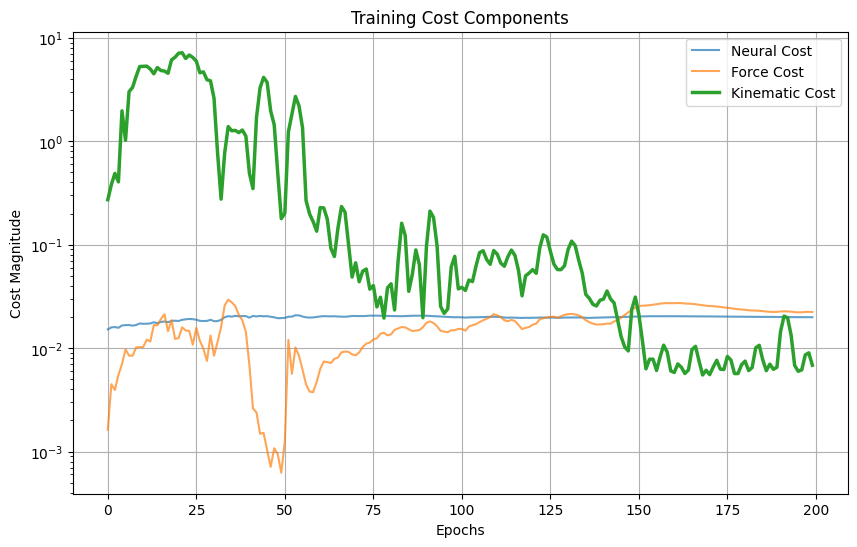

In [44]:
plot_cost_history(target_results, perturbation_idx)

In [45]:
import matplotlib.cm as cm
import numpy as np

def plot_trajectory_vs_time(epoch_qpos_over_time, epoch_metadata, dt=0.01, plot_step=50):
    """
    Plots the X and Y coordinates separately over time for specific epochs (e.g., every 50).
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    num_epochs = len(epoch_qpos_over_time)
    
    # Generate indices: 0, 50, 100... and always include the final epoch if not already included
    indices_to_plot = list(range(0, num_epochs, plot_step))
    if (num_epochs - 1) not in indices_to_plot and num_epochs > 0:
        indices_to_plot.append(num_epochs - 1)

    # Use a colormap to visualize progress (Red = Start, Blue = End)
    colormap = cm.get_cmap('coolwarm')

    for i in indices_to_plot:
        # Safety check
        if i >= len(epoch_metadata):
            break

        trajectory = epoch_qpos_over_time[i]
        meta = epoch_metadata[i]
        direction = meta["direction"]
        load = meta["load"]
        
        # Unzip x and y
        x_vals, y_vals = zip(*trajectory)
        time_axis = np.arange(len(x_vals)) * dt
        
        # Calculate color based on training progress
        color = colormap(i / max(1, num_epochs - 1))
        
        # Plot X
        ax1.plot(time_axis, x_vals, label=f"Ep {i+1}: {direction} ({load})", color=color, alpha=0.8)
        
        # Plot Y
        ax2.plot(time_axis, y_vals, color=color, alpha=0.8)

    # Styling
    ax1.set_title(f"X Position over Time (Every {plot_step} Epochs)")
    ax1.set_ylabel("X (m)")
    ax1.grid(True)
    ax1.axhline(0, color='k', linestyle='--', linewidth=1) 

    ax2.set_title(f"Y Position over Time (Every {plot_step} Epochs)")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Y (m)")
    ax2.grid(True)
    ax2.axhline(0, color='k', linestyle='--', linewidth=1) 
    
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.tight_layout()
    plt.show()

def plot_desired_vs_actual_trajectories(epoch_metadata, epoch_qpos_over_time, perturbation_directions, plot_step=50):
    """
    Plot the desired perturbation directions alongside the actual end-effector trajectories
    for specific epochs (e.g., every 50).
    """
    # Scale the perturbation directions to match the expected movement scale (~0.1 m)
    scale_factor = 0.01 
    scaled_perturbation_directions = {k: v * scale_factor for k, v in perturbation_directions.items()}

    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot desired perturbation directions (Background)
    for direction, vector in scaled_perturbation_directions.items():
        ax.arrow(0, 0, vector[0], vector[1], color="gray", label=f"Desired {direction}", alpha=0.3, head_width=0.005)

    num_epochs = len(epoch_qpos_over_time)
    
    # Generate indices: 0, 50, 100... and always include the final epoch
    indices_to_plot = list(range(0, num_epochs, plot_step))
    if (num_epochs - 1) not in indices_to_plot and num_epochs > 0:
        indices_to_plot.append(num_epochs - 1)

    # Use a colormap (Red = Start, Blue = End)
    colormap = cm.get_cmap('coolwarm')

    for i in indices_to_plot:
        # Safety check
        if i >= len(epoch_metadata):
            break

        trajectory = epoch_qpos_over_time[i]
        metadata = epoch_metadata[i]
        direction = metadata["direction"]
        load = metadata["load"]
        
        x, y = zip(*trajectory)
        
        # Color based on progress
        color = colormap(i / max(1, num_epochs - 1))
        
        # Make the lines distinct
        label = f"Ep {i+1}: {direction}"
        ax.plot(x, y, label=label, color=color, linewidth=2, alpha=0.8)

    # Finalize the plot
    ax.set_title(f"Trajectory Evolution (Every {plot_step} Epochs)")
    ax.set_xlabel("X Position (m)")
    ax.set_ylabel("Y Position (m)")
    ax.legend(title="Epochs", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid()
    # Ensure aspect ratio is equal so circles look like circles
    ax.set_aspect('equal', adjustable='box') 
    plt.tight_layout()
    plt.show()

/var/folders/q_/xhgs30s966s2xsy_tl8w2k680000gp/T/ipykernel_30417/1749509229.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('coolwarm')


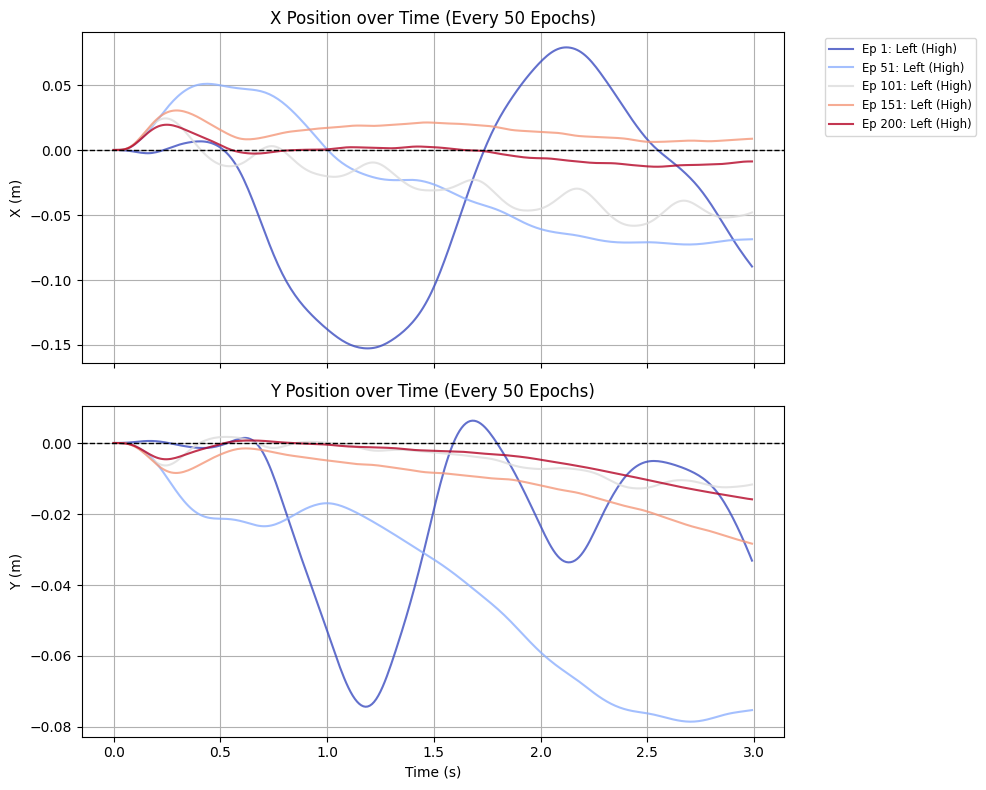

/var/folders/q_/xhgs30s966s2xsy_tl8w2k680000gp/T/ipykernel_30417/1749509229.py:82: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('coolwarm')


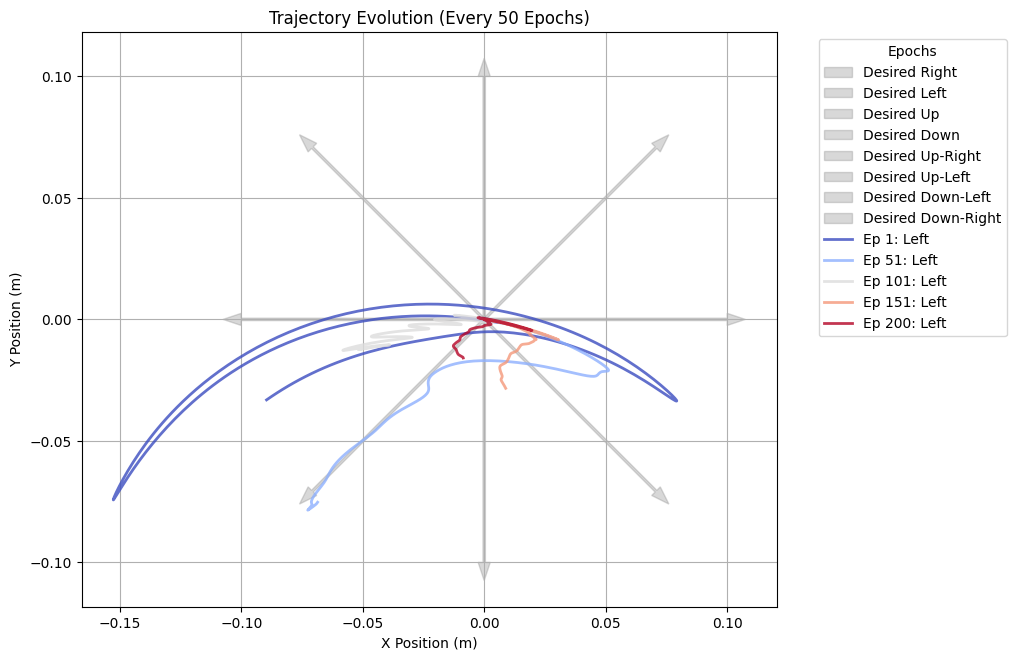

In [46]:
plot_trajectory_vs_time(epoch_qpos_over_time, epoch_metadata, dt=0.01)
plot_desired_vs_actual_trajectories(epoch_metadata, epoch_qpos_over_time, perturbation_directions, plot_step=50)

### Plots

In [47]:
# Define perturbation direction names
perturbation_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]

# Group results by load condition and perturbation direction
low_load_results = {}
high_load_results = {}

for epoch_idx, metadata in enumerate(epoch_metadata):
    perturbation_idx = perturbation_names.index(metadata["direction"])
    if perturbation_idx >= len(target_results):
        continue

for epoch_idx, metadata in enumerate(epoch_metadata):
    perturbation_idx = perturbation_names.index(metadata["direction"])
    if epoch_idx >= len(target_results[perturbation_idx]["pose_errors"]):
        continue

    key = (metadata["load"], perturbation_idx)
    if metadata["load"] == "Low":
        if key not in low_load_results:
            low_load_results[key] = {"pose_errors": [], "rewards": []}
        low_load_results[key]["pose_errors"].append(target_results[perturbation_idx]["pose_errors"][epoch_idx])
        low_load_results[key]["rewards"].append(target_results[perturbation_idx]["rewards"][epoch_idx])

    elif metadata["load"] == "High":
        if key not in high_load_results:
            high_load_results[key] = {"pose_errors": [], "rewards": []}
        high_load_results[key]["pose_errors"].append(target_results[perturbation_idx]["pose_errors"][epoch_idx])
        high_load_results[key]["rewards"].append(target_results[perturbation_idx]["rewards"][epoch_idx])

In [48]:
def pad_and_compute_mean_std(data, max_length):
    """Pad data with NaN to the maximum length and compute mean and standard deviation."""
    padded_data = np.array([np.pad(epoch, (0, max_length - len(epoch)), constant_values=np.nan) for epoch in data])
    mean = np.nanmean(padded_data, axis=0)
    std = np.nanstd(padded_data, axis=0)
    return mean, std

def plot_mean_and_std(ax, x, mean, std, label, color, line_style="solid", alpha=0.1):
    """Plot mean and standard deviation as a shaded region."""
    ax.plot(x, mean, label=label, color=color, linestyle=line_style)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=alpha)

def plot_pose_error(ax, grouped_results):
    """Plot pose error over time for all perturbations."""
    perturbation_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    num_perturbations = len(perturbation_names)
    colormap = colormaps["tab10"].resampled(num_perturbations)

    for (load, perturbation_idx), perturbation_data in grouped_results.items():
        pose_errors = perturbation_data["pose_errors"]
        if not pose_errors:
            continue

        max_length = max(len(epoch) for epoch in pose_errors)
        if len(pose_errors) > 1:  # If multiple trials exist, compute mean and std
            mean, std = pad_and_compute_mean_std(pose_errors, max_length)
            label = f"{perturbation_names[perturbation_idx]} ({load})"
            color = colormap(perturbation_idx / num_perturbations)
            plot_mean_and_std(ax, range(len(mean)), mean, std, label=label, color=color)
        else:  # If only one trial exists, plot it directly
            single_trial = np.pad(pose_errors[0], (0, max_length - len(pose_errors[0])), constant_values=np.nan)
            label = f"{perturbation_names[perturbation_idx]} ({load})"
            color = colormap(perturbation_idx / num_perturbations)
            ax.plot(range(len(single_trial)), single_trial, label=label, color=color)

    ax.set_title("Pose error over time")
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Pose error")
    ax.legend(title="Perturbations")
    ax.grid()

def plot_reward(ax, perturbation_results):
    """Plot reward over time for all perturbations."""
    # Define perturbation direction names
    perturbation_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    num_perturbations = len(perturbation_names)
    colormap = colormaps["tab10"].resampled(num_perturbations)

    for (load, perturbation_idx), perturbation_data in perturbation_results.items():
        rewards = perturbation_data["rewards"]
        if not rewards:
            continue

        max_length = max(len(epoch) for epoch in rewards)
        mean, std = pad_and_compute_mean_std(rewards, max_length)
        color = colormap(perturbation_idx / num_perturbations)  # Use the direction index
        label = f"{perturbation_names[perturbation_idx]} ({load})"  # Include load in the label
        plot_mean_and_std(ax, range(len(mean)), mean, std, label=label, color=color)
    
    ax.set_title("Reward over time")
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Reward")
    ax.legend(title="Perturbations")
    ax.grid()

def plot_costs(ax, epoch_costs_over_time):
    """Plot aggregated cost components over time (mean and std) for all epochs."""
    cost_keys = ["neural", "force", "kinematic", "total"]
    colors = {"neural": "orange", "force": "cyan", "kinematic": "blue", "total": "red"} 
    line_styles = {"total": "--"}

    # Initialize storage for all costs across epochs
    all_costs = {key: [] for key in cost_keys}

    # Collect costs for all epochs
    for epoch_costs in epoch_costs_over_time:
        for key in cost_keys:
            # Detach tensors and convert to NumPy arrays
            cost_values = [value.detach().numpy() if isinstance(value, torch.Tensor) else value for value in epoch_costs[key]]
            all_costs[key].append(cost_values)

    # Compute mean and std for each cost component
    for key in cost_keys:
        max_length = max(len(epoch) for epoch in all_costs[key])  # Find the maximum length across epochs
        mean, std = pad_and_compute_mean_std(all_costs[key], max_length)  # Pad and compute mean/std

        # Plot mean and std
        line_style = line_styles.get(key, "solid")  # Use "dashed" for "total", "solid" for others
        plot_mean_and_std(ax, range(len(mean)), mean, std, label=f"{key.capitalize()} Cost", color=colors[key], line_style=line_style, alpha=0.2)

    ax.set_title("Aggregated Cost Components Over Time")
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Cost")
    ax.legend()
    ax.grid()

def plot_selected_epochs(epoch_metadata, epoch_qpos_over_time, epoch_external_loads):
    """
    Plot torque and position data for selected epochs, grouped by one randomly selected direction.

    Parameters:
        epoch_metadata (list): List of dictionaries containing metadata for each epoch.
        epoch_qpos_over_time (list): List of (x, y) positions over time for each epoch.
        epoch_external_loads (list): List of external torque data for each epoch.
    """
    # Define the directions and load conditions
    directions = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    load_conditions = ["Low", "High"]

    # Shuffle directions to try them in random order
    random.shuffle(directions)

    for selected_direction in directions:
        # Group epochs by direction and load condition
        epochs_by_direction_and_load = {load: [] for load in load_conditions}
        for epoch, metadata in enumerate(epoch_metadata):
            direction = metadata["direction"]
            load = metadata["load"]
            if direction == selected_direction and load in epochs_by_direction_and_load:
                epochs_by_direction_and_load[load].append(epoch)

        # Check available loads
        low_epochs = epochs_by_direction_and_load["Low"]
        high_epochs = epochs_by_direction_and_load["High"]

        if not low_epochs and not high_epochs:  # No data for this direction
            continue  # Try the next direction

        # Create the figure and axes
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Two plots: torque and position
        ax_torque, ax_position = axes

        # Add a common title for the plots
        fig.suptitle(
            f"Torques and End-Effector Trajectory - {selected_direction}",
            fontsize=14, fontweight="bold"
        )

        # Plot for Low Load if available
        if low_epochs:
            low_epoch = random.choice(low_epochs)
            external_load_low = np.array(epoch_external_loads[low_epoch])
            ax_torque.plot(external_load_low[:, 0], label="Shoulder Torque (Low Load)", linestyle="-", color="cyan")
            ax_torque.plot(external_load_low[:, 1], label="Elbow Torque (Low Load)", linestyle="-", color="orange")
            qpos_x_low, qpos_y_low = zip(*epoch_qpos_over_time[low_epoch])
            ax_position.plot(qpos_x_low, qpos_y_low, label="Trajectory (Low Load)", linestyle="-", color="green")
            ax_position.scatter(qpos_x_low[-1], qpos_y_low[-1], color="green", label="Final Position (Low Load)")

        # Plot for High Load if available
        if high_epochs:
            high_epoch = random.choice(high_epochs)
            external_load_high = np.array(epoch_external_loads[high_epoch])
            ax_torque.plot(external_load_high[:, 0], label="Shoulder Torque (High Load)", linestyle="-", color="blue")
            ax_torque.plot(external_load_high[:, 1], label="Elbow Torque (High Load)", linestyle="-", color="red")
            qpos_x_high, qpos_y_high = zip(*epoch_qpos_over_time[high_epoch])
            ax_position.plot(qpos_x_high, qpos_y_high, label="Trajectory (High Load)", linestyle=(0, (1, 3)), color="red")
            ax_position.scatter(qpos_x_high[0], qpos_y_high[0], color="blue", label="Initial Position")
            ax_position.scatter(qpos_x_high[-1], qpos_y_high[-1], color="red", label="Final Position (High Load)")

        # Finalize the plots
        ax_torque.set_xlabel("Time Steps")
        ax_torque.set_ylabel("Torque")
        ax_torque.legend()
        ax_torque.grid()

        ax_position.set_xlabel("X Position")
        ax_position.set_ylabel("Y Position")
        ax_position.legend()
        ax_position.grid()

        plt.tight_layout(pad=2.0)
        plt.show()
        return

    print("No direction had enough data to plot.")

/var/folders/q_/xhgs30s966s2xsy_tl8w2k680000gp/T/ipykernel_30417/1804206046.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Perturbations")
/var/folders/q_/xhgs30s966s2xsy_tl8w2k680000gp/T/ipykernel_30417/1804206046.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Perturbations")


ValueError: max() arg is an empty sequence

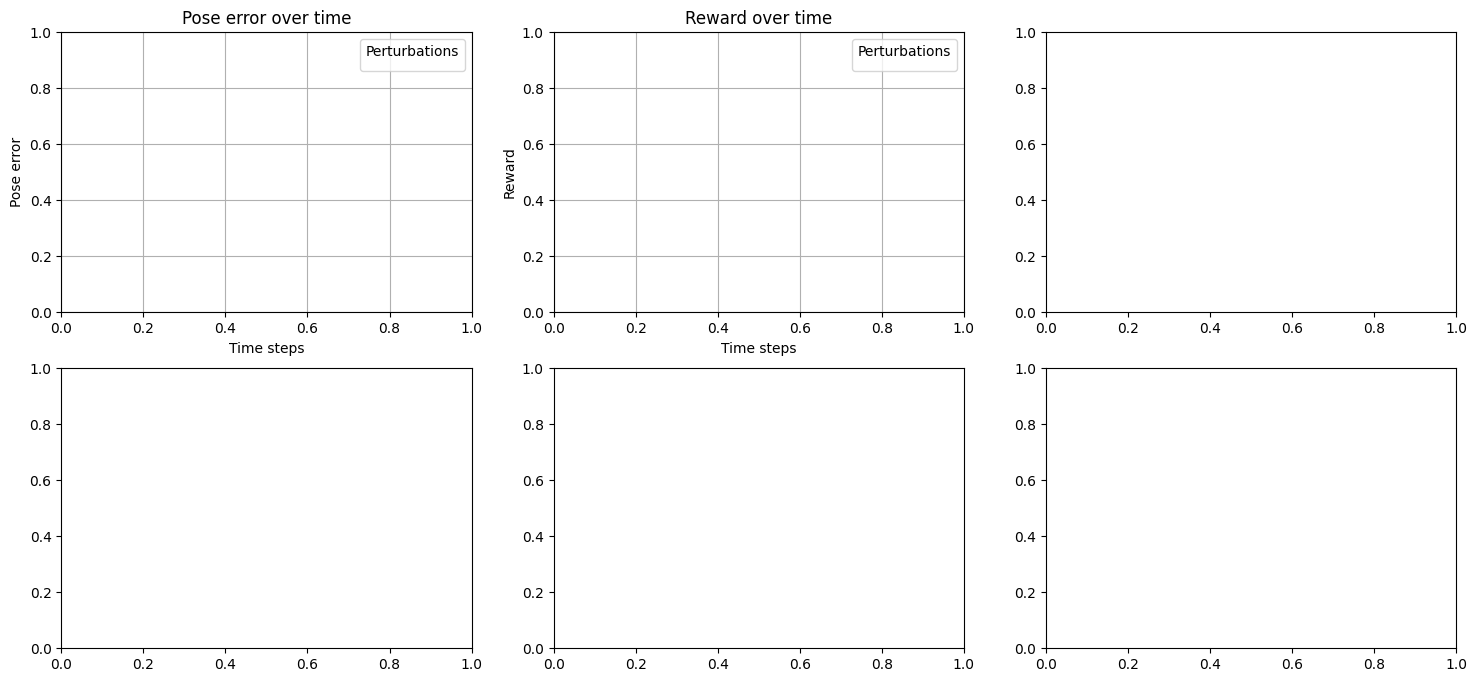

In [49]:
# Plot the results
fig, axes = plt.subplots(2, 3, figsize=(18, 8))  # Create a 2x3 grid of subplots

# Plot for low load conditions (first row)
plot_pose_error(axes[0, 0], low_load_results)
plot_reward(axes[0, 1], low_load_results)
plot_costs(axes[0, 2], [epoch_costs for i, epoch_costs in enumerate(epoch_costs_over_time) if epoch_metadata[i]["load"] == "Low"])

# Plot for high load conditions (second row)
plot_pose_error(axes[1, 0], high_load_results)
plot_reward(axes[1, 1], high_load_results)
plot_costs(axes[1, 2], [epoch_costs for i, epoch_costs in enumerate(epoch_costs_over_time) if epoch_metadata[i]["load"] == "High"])

# Add suptitles for each row
fig.text(0.5, 0.95, "Low Load Conditions", ha="center", fontsize=16, fontweight="bold")
fig.text(0.5, 0.48, "High Load Conditions", ha="center", fontsize=16, fontweight="bold")

# Adjust layout
plt.tight_layout(h_pad=4.0, pad=4.0)
plt.show()

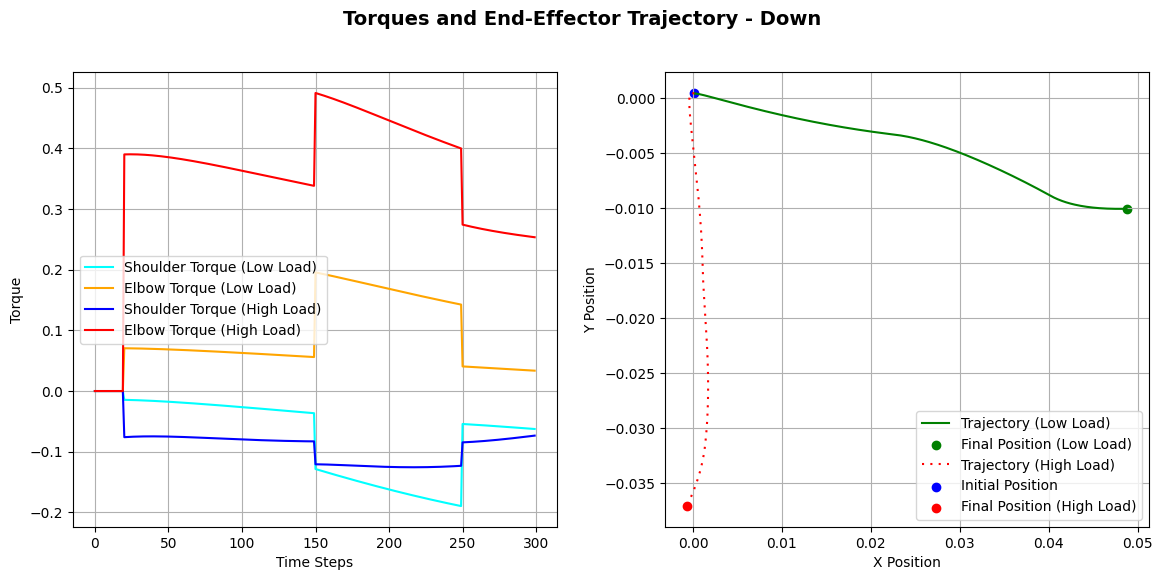

In [ ]:
plot_selected_epochs(epoch_metadata, epoch_qpos_over_time, epoch_external_loads)

In [ ]:
def plot_trajectories(epoch_metadata, epoch_qpos_over_time):
    """
    Plot average end-effector trajectories in the 2D plane (x-y) for each load condition and perturbation direction.

    Parameters:
        epoch_metadata (list): List of dictionaries containing metadata for each epoch.
        epoch_qpos_over_time (list): List of (x, y) positions over time for each epoch.
    """
    # Define perturbation direction names and load conditions
    perturbation_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    load_conditions = ["Low", "High"]
    num_directions = len(perturbation_names)

    # Create a colormap for the perturbation directions
    colormap = colormaps["tab10"].resampled(num_directions)

    # Group trajectories by load condition and perturbation direction
    grouped_trajectories = {load: {direction: [] for direction in perturbation_names} for load in load_conditions}
    for epoch_idx, metadata in enumerate(epoch_metadata):
        load = metadata["load"]
        direction = metadata["direction"]
        grouped_trajectories[load][direction].append(epoch_qpos_over_time[epoch_idx])

    # Create the figure
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot average trajectories for each load condition and perturbation direction
    for load_idx, load in enumerate(load_conditions):
        for direction_idx, direction in enumerate(perturbation_names):
            trajectories = grouped_trajectories[load][direction]
            if not trajectories:
                continue  # Skip if no trajectories for this load and direction

            # Compute the average trajectory
            max_length = max(len(traj) for traj in trajectories)
            padded_trajectories = np.array([
                np.pad(traj, ((0, max_length - len(traj)), (0, 0)), constant_values=np.nan)
                for traj in trajectories
            ])
            mean_trajectory = np.nanmean(padded_trajectories, axis=0)

            # Plot the average trajectory
            x, y = mean_trajectory[:, 0], mean_trajectory[:, 1]
            label = f"{direction} ({load})"
            color = colormap(direction_idx / num_directions)
            ax.plot(x, y, label=label, color=color, alpha=0.8)

    # Finalize the plot
    ax.set_title("Average End-Effector Trajectories in 2D Plane")
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    ax.legend(title="Perturbations and Loads", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid()
    plt.tight_layout()
    plt.show()

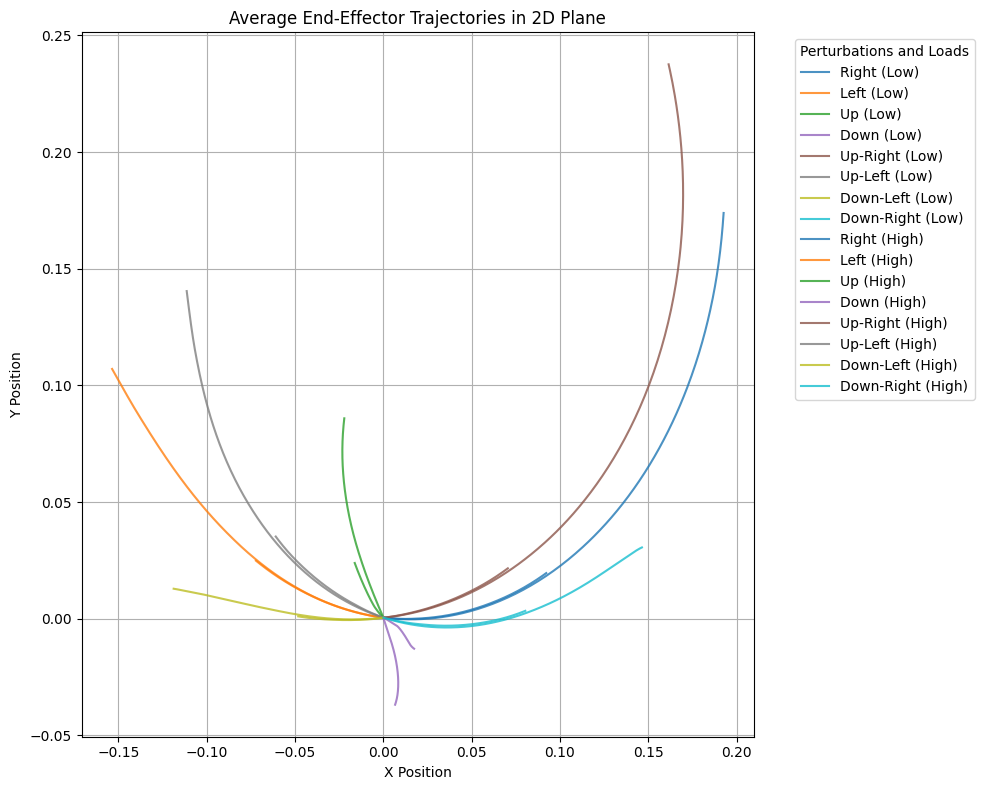

In [ ]:
# Plot end-effector trajectories
plot_trajectories(epoch_metadata, epoch_qpos_over_time)

In [ ]:
def plot_desired_vs_actual_trajectories(epoch_metadata, epoch_qpos_over_time, perturbation_directions):
    """
    Plot the desired perturbation directions alongside the actual end-effector trajectories.

    Parameters:
        epoch_metadata (list): List of dictionaries containing metadata for each epoch.
        epoch_qpos_over_time (list): List of (x, y) positions over time for each epoch.
        perturbation_directions (dict): Dictionary of desired perturbation directions in Cartesian space.
    """
    # Scale the perturbation directions to match the expected movement scale (~0.1 m)
    scale_factor = 0.01  # Desired movement scale (10 cm)
    scaled_perturbation_directions = {k: v * scale_factor for k, v in perturbation_directions.items()}

    # Create the figure
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot desired perturbation directions
    for direction, vector in scaled_perturbation_directions.items():
        ax.arrow(0, 0, vector[0], vector[1], color="gray", label=f"Desired {direction}", alpha=0.5, head_width=0.005)

    # Plot actual trajectories
    for epoch_idx, trajectory in enumerate(epoch_qpos_over_time):
        metadata = epoch_metadata[epoch_idx]
        direction = metadata["direction"]
        load = metadata["load"]
        x, y = zip(*trajectory)
        ax.plot(x, y, label=f"Actual {direction} ({load})", alpha=0.7)

    # Finalize the plot
    ax.set_title("Desired vs. Actual End-Effector Trajectories")
    ax.set_xlabel("X Position (m)")
    ax.set_ylabel("Y Position (m)")
    ax.legend(title="Trajectories", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid()
    plt.tight_layout()
    plt.show()

/var/folders/q_/xhgs30s966s2xsy_tl8w2k680000gp/T/ipykernel_28695/308260603.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


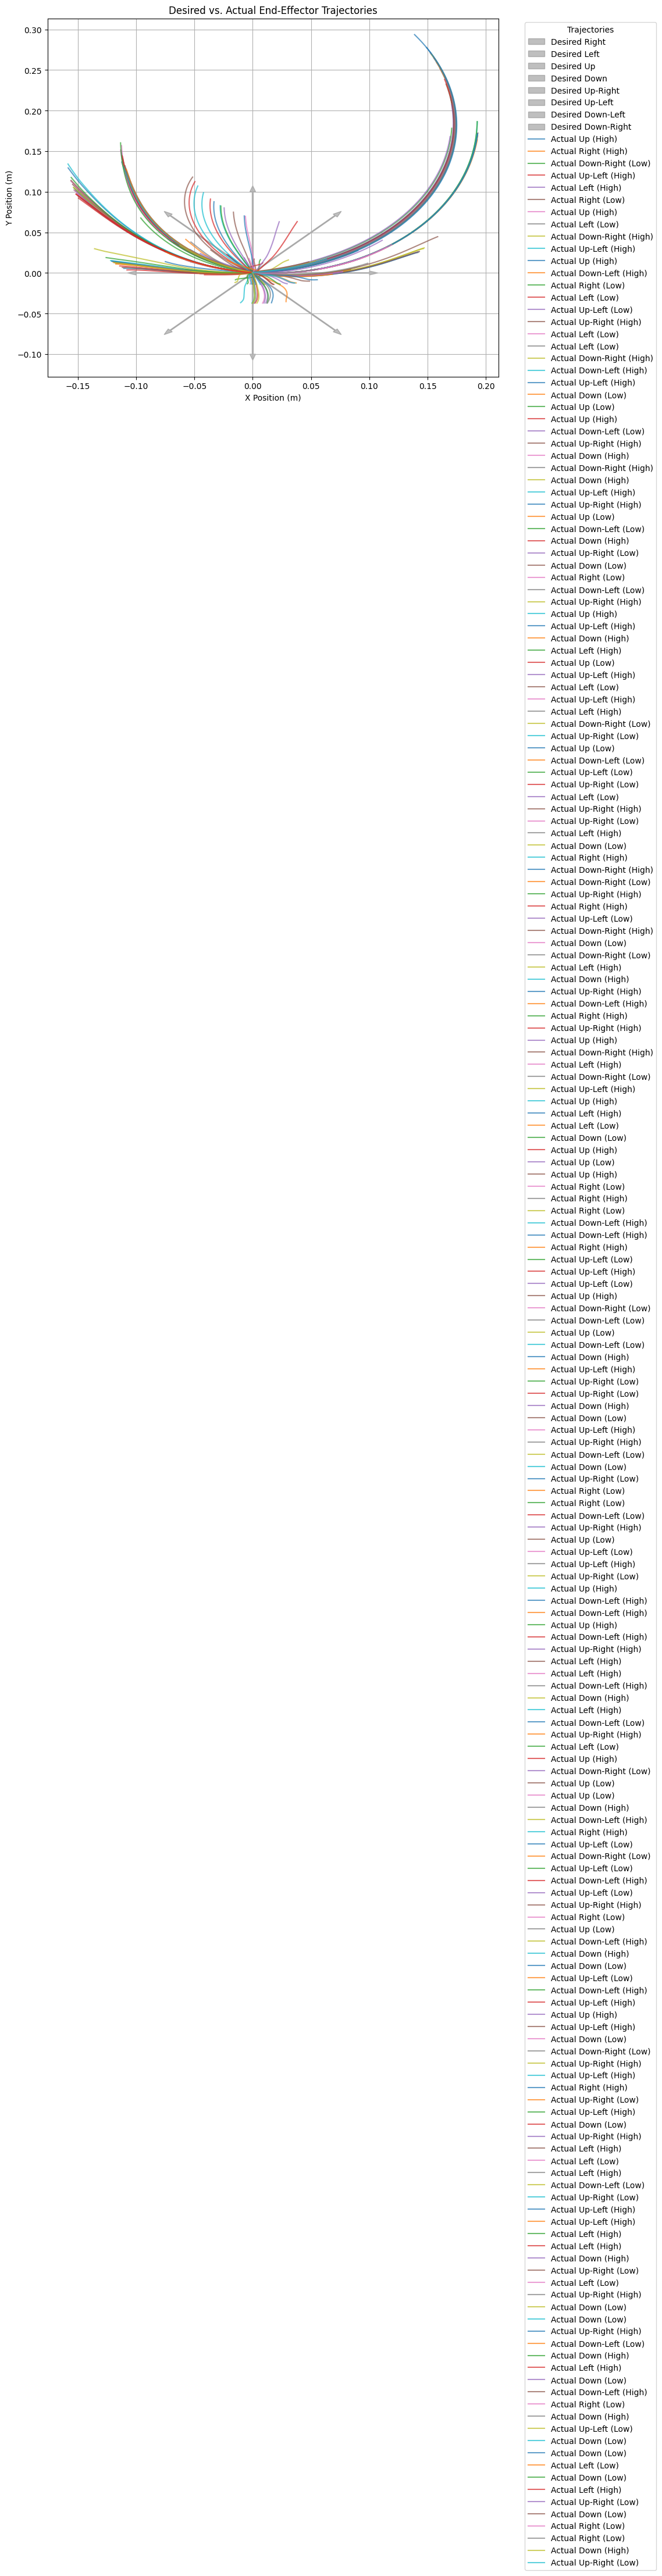

In [ ]:
plot_desired_vs_actual_trajectories(epoch_metadata, epoch_qpos_over_time, perturbation_directions)